Using cache found in C:\Users\sahar/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Encoded reference: coke-can.png  shape=(512,)
Prototype ready, shape=(512,), any NaN=False

0: 448x640 4 cups, 154.8ms
Speed: 42.3ms preprocess, 154.8ms inference, 3.6ms postprocess per image at shape (1, 3, 448, 640)
YOLO detected 4 objects
  box 0: cup, cosine_sim=0.7829  ✓ MATCH
  box 1: cup, cosine_sim=0.8218  ✓ MATCH
  box 2: cup, cosine_sim=0.8076  ✓ MATCH
  box 3: cup, cosine_sim=0.7947  ✓ MATCH

FINAL COUNT = 4


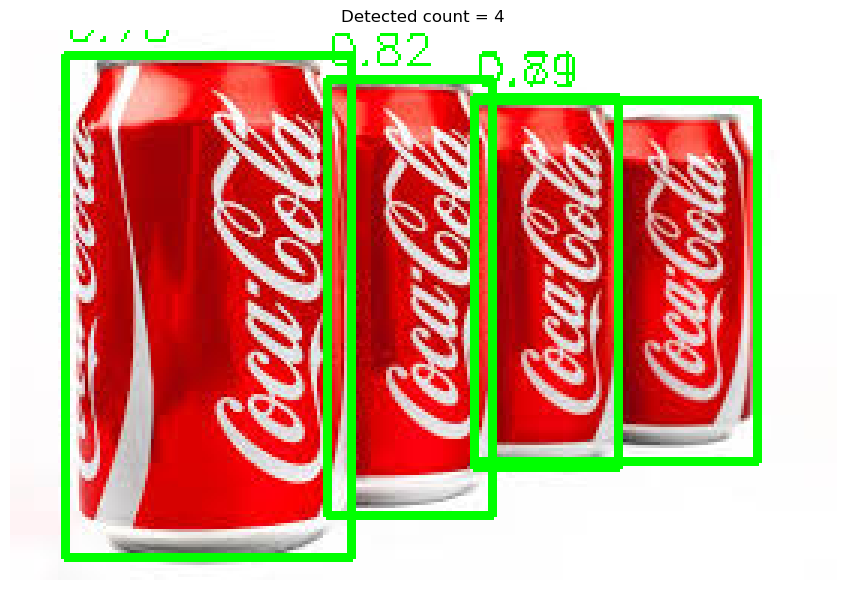

Saved result.png


In [1]:
# ── Step 1: Imports ──────────────────────────────────────────────────────────
from ultralytics import YOLO
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

# ── Step 2: Load Detector (YOLOv8) ───────────────────────────────────────────
yolo = YOLO('yolov8n.pt')

# ── Step 3: Load Encoder (ResNet18) ──────────────────────────────────────────
encoder = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
encoder = torch.nn.Sequential(*list(encoder.children())[:-1])  # remove classifier
encoder.eval()

# ── Step 4: Preprocessing & encoding helpers ─────────────────────────────────
def preprocess_image(img):
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img, dtype=torch.float32).unsqueeze(0)

def encode(img):
    with torch.no_grad():
        x = preprocess_image(img)
        features = encoder(x).squeeze().numpy()
    return features / np.linalg.norm(features)  # L2 normalize

# ── Step 5: Build prototype from reference images ────────────────────────────
#   ⚠️ FIX: populate ref_embeddings BEFORE computing the prototype
reference_images = ['coke-can.png']
ref_embeddings = []

for path in reference_images:
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read reference image: {path}")
    embedding = encode(img)
    ref_embeddings.append(embedding)
    print(f"Encoded reference: {path}  shape={embedding.shape}")

prototype = np.mean(ref_embeddings, axis=0)
prototype = prototype / np.linalg.norm(prototype)   # L2 normalize
print(f"Prototype ready, shape={prototype.shape}, any NaN={np.isnan(prototype).any()}")

# ── Step 6: Detect objects in the scene ──────────────────────────────────────
scene = cv2.imread('./coke-cans.jpg')
if scene is None:
    raise FileNotFoundError("Could not read scene image: coke-cans.jpg")

# conf=0.1 catches more candidates; yolo has no 'can' class so expect 'cup'/'bottle'
results = yolo(scene, conf=0.1)[0]
print(f"YOLO detected {len(results.boxes)} objects")

# ── Step 7: Count matching objects ───────────────────────────────────────────
count = 0
threshold = 0.75   # slightly relaxed — tune as needed

for i, box in enumerate(results.boxes.xyxy):
    x1, y1, x2, y2 = map(int, box.tolist())
    crop = scene[y1:y2, x1:x2]
    if crop.size == 0:
        continue

    emb  = encode(crop)
    sim  = float(np.dot(emb, prototype))   # both L2-normalised → cosine similarity

    cls_id = int(results.boxes.cls[i].item())
    cls_name = yolo.names[cls_id]
    print(f"  box {i}: {cls_name}, cosine_sim={sim:.4f}", end="")

    if sim > threshold:
        count += 1
        cv2.rectangle(scene, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(scene, f"{sim:.2f}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        print("  ✓ MATCH")
    else:
        print("  ✗ skip (below threshold)")

# ── Step 8: Show result ───────────────────────────────────────────────────────
print(f"\nFINAL COUNT = {count}")

scene_rgb = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(scene_rgb)
plt.title(f"Detected count = {count}")
plt.axis("off")
plt.tight_layout()
plt.savefig("result.png", dpi=150)
plt.show()
print("Saved result.png")